In [ ]:
import importlib.util
import os
import json
from dotenv import load_dotenv
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from standardRegArchitercture import SimpleNet

load_dotenv() 

True

In [ ]:
import os
import torch

# Path to the directory containing the saved networks
directory = "/Users/dani/Documents/GitHub/Large-Scale-Design-and-Analysis-of-Neural-Networks/Working Networks"

# List all model files in the directory (assuming .pt or .pth extensions)
model_files = [f for f in os.listdir(directory) if f.endswith('.pt') or f.endswith('.pth')]

# Load models into a dictionary
models = {}
for model_file in model_files:
    model_path = os.path.join(directory, model_file)
    model_name = os.path.splitext(model_file)[0]  # Use the file name (without extension) as the key
    models[model_name] = torch.load(model_path)

# Print the loaded models (or access them by name)
for name, model in models.items():
    print(f"Loaded model: {name}")
    print(model)

/var/folders/2_/1m71dq416yx4_0rjdssjxckm0000gn/T/ipykernel_22180/2089468232.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  models[model_name] = torch.load(model_path)


Loaded model: network_90
OrderedDict({'fc1.weight': tensor([[ 0.2124, -0.3755],
        [-0.5461,  0.5794],
        [-0.1270, -0.4420],
        [-0.6228,  0.2560],
        [-0.4288, -0.6081]], device='mps:0'), 'fc1.bias': tensor([ 0.3610, -0.4812, -0.4734,  0.4717, -0.0235], device='mps:0'), 'fc2.weight': tensor([[-0.1971, -0.3368,  0.1050, -0.2168,  0.3703],
        [ 0.2177,  0.0784,  0.2708, -0.3306,  0.1593],
        [ 0.3723,  0.0911, -0.0443,  0.3322, -0.0278],
        [-0.4132, -0.4036, -0.4428, -0.3106,  0.4164],
        [ 0.3792,  0.2181,  0.0540,  0.3010, -0.0684]], device='mps:0'), 'fc2.bias': tensor([-0.1012,  0.3841,  0.1598, -0.0880,  0.2137], device='mps:0'), 'fc3.weight': tensor([[-0.4281, -0.2208, -0.2675, -0.0979,  0.3181]], device='mps:0'), 'fc3.bias': tensor([-0.0186], device='mps:0')})
Loaded model: network_63
OrderedDict({'fc1.weight': tensor([[-0.2471,  0.3239],
        [-0.5635, -0.2296],
        [-0.4744, -0.3527],
        [ 0.6646,  0.1061],
        [ 0.5984, 

In [11]:
import torch.nn as nn 
class SimpleNet(nn.Module):
    # 2 because a, b
    input_size = 2
    # num of hidden neurons
    hidden_size = 5
    output_size = 1
    def __init__(self):
        super(SimpleNet, self).__init__()
        self.fc1 = nn.Linear(self.input_size, self.hidden_size)
        # Right now RELU but we can change later
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(self.hidden_size, self.hidden_size)
        self.fc3 = nn.Linear(self.hidden_size, self.output_size)
        
    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        out = self.relu(out)
        out = self.fc3(out)
        return out


In [ ]:
NUM_BINS = 100

config_file_path = os.getenv('CONFIG_FILE_PATH')
print(config_file_path)
with open(config_file_path, "r") as f:
    config = json.load(f)

#Load in the networks
output_dir = config.get("output_dir")
loaded_state_dict = torch.load(f'{output_dir}/trainedNetworks.pt')

#create new instantiations to contain the saved networks
num_networks = config.get("num_networks")
networks = []
for n in range(num_networks):
    networks.append(SimpleNet())

for i, network in enumerate(networks):
    state_dict_key = f'network_{i}'
    network.load_state_dict(loaded_state_dict[state_dict_key])




/var/folders/2_/1m71dq416yx4_0rjdssjxckm0000gn/T/ipykernel_22180/2959957128.py:17: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(file_path)


Successfully loaded 1000 networks from /Users/dani/Documents/GitHub/Large-Scale-Design-and-Analysis-of-Neural-Networks/Working Networks.


In [13]:
%matplotlib inline

In [ ]:
def __getMinOrMax__(networks, layerNum, getMin):
    """
    Parameters:
    - networks: an array of trained pytorch networks where the layers are nn.Linear
    - layer: an int representing the fully connected layer to access
    - getMin: a boolean indicating wheter to get the min or max
    Outputs: the minimum or maximum weight in some array of neural networks
    """
    weights = []
    curLayer = -1
    for network in networks:
        for layer in network.children():
            if isinstance(layer, nn.Linear):
                curLayer += 1
                if curLayer == layerNum:
                    #.cpu moves the tensor from the gpu to cpu if it is there in order to use .numpy()
                    weights.extend(layer.weight.data.cpu().numpy().flatten())
        curLayer = -1
    
    if getMin:
        return min(weights) - 1e-6 #small adjustment to account for floating point rounding error, issue occured with getting the upper bound of the max bin
    else:
        return max(weights) + 1e-6

min_weight = __getMinOrMax__(networks, 0, True)
max_weight = __getMinOrMax__(networks, 0, False)
min_weight1 = __getMinOrMax__(networks, 1, True)
max_weight1 = __getMinOrMax__(networks, 1, False)



In [ ]:
import numpy as np

layer_weight_distributions = []
layer_bin_ranges = []
network_fc_indices = []
#for each fully connected layer, create matrix of shape (N, M, B) where
#N = num neurons in layer
#M = num neurons in previous layer
#B = number of bins
    
layers = networks[0].children()
fcLayerNum = -1
for index, layer in enumerate(layers):
    if isinstance(layer, nn.Linear):
        fcLayerNum += 1
        layerMin = getMinOrMax(networks, fcLayerNum, True)
        layerMax = getMinOrMax(networks, fcLayerNum, False)
        #for each layer make an array of shape (num of neurons in layer, num of inputs to layer, num of bins)
        network_fc_indices.append(index)
        layer_shape = layer.weight.shape
        layer_weight_distributions.append(np.zeros(layer_shape + (NUM_BINS,), dtype=int))
        #subtract 1 to make 0-indexed
        bin_edges = np.histogram_bin_edges(a=[], bins=(NUM_BINS), range=(layerMin, layerMax))
        layer_bin_ranges.append(bin_edges)

        
        
#Generate matrix of shape layer, network, neuron, incoming weight
network_weights = []
for index, layer_index in enumerate(network_fc_indices):
    network_weights_per_layer = []
    for network in networks:
        net_layers = list(network.children())
        network_weights_per_layer.append(net_layers[layer_index].weight.data.numpy())
    network_weights.append(network_weights_per_layer)

# print(layer_weight_distributions[0].shape)
print(layer_bin_ranges)
#print the first weight of the first fully connected layer of the first network
print(network_weights)

[array([-0.70673107, -0.69252602, -0.67832098, -0.66411593, -0.64991089,
       -0.63570584, -0.6215008 , -0.60729575, -0.5930907 , -0.57888566,
       -0.56468061, -0.55047557, -0.53627052, -0.52206548, -0.50786043,
       -0.49365539, -0.47945034, -0.4652453 , -0.45104025, -0.4368352 ,
       -0.42263016, -0.40842511, -0.39422007, -0.38001502, -0.36580998,
       -0.35160493, -0.33739989, -0.32319484, -0.3089898 , -0.29478475,
       -0.2805797 , -0.26637466, -0.25216961, -0.23796457, -0.22375952,
       -0.20955448, -0.19534943, -0.18114439, -0.16693934, -0.1527343 ,
       -0.13852925, -0.1243242 , -0.11011916, -0.09591411, -0.08170907,
       -0.06750402, -0.05329898, -0.03909393, -0.02488889, -0.01068384,
        0.0035212 ,  0.01772625,  0.03193129,  0.04613634,  0.06034139,
        0.07454643,  0.08875148,  0.10295652,  0.11716157,  0.13136661,
        0.14557166,  0.1597767 ,  0.17398175,  0.18818679,  0.20239184,
        0.21659689,  0.23080193,  0.24500698,  0.25921202,  0.2

In [18]:

for layer_num, layer_distribution in enumerate(layer_weight_distributions):
    #iterate over neurons in layer
    for i in range(layer_distribution.shape[0]):  
        #iterate over incoming weights to neuron
        for j in range(layer_distribution.shape[1]):  # incoming weights
            # for this weight, iterate over each network to add data to corresponding bin
            for network in network_weights[layer_num]:
                #select network[neuron i, incoming weight j]
                weight = network[i][j]
                corresponding_bin = np.digitize(weight, layer_bin_ranges[layer_num], right=False) - 1
                if corresponding_bin >= NUM_BINS or corresponding_bin < 0:
                    print(weight)
                    print(corresponding_bin)
                
                layer_weight_distributions[layer_num][i][j][corresponding_bin] += 1


#select layer 1, neuron 10, incoming weight 2, and the last bin


In [19]:
print(layer_weight_distributions)


[array([[[16,  7,  5,  7,  8, 10, 10,  6,  5, 10, 14,  9,  9,  8, 17, 17,
         10, 10,  6, 15, 11, 14, 14,  7, 15, 13, 13, 17,  6, 15,  8,  8,
         13,  8,  1, 11,  8, 10, 13, 12, 10, 11,  8,  8,  4,  6,  9,  8,
         11,  8, 18, 17, 10,  9, 13,  3, 13,  7,  7, 13, 15, 17, 16,  7,
         13, 11, 11, 11, 11, 10,  9, 13, 10, 12,  8, 11,  9, 10,  9,  9,
         11,  7,  7,  7, 10, 15,  7, 10,  8, 12,  7,  6,  7, 21,  9,  4,
          4,  8,  4,  5],
        [12,  6, 10, 13, 11,  7,  8, 10,  8,  9,  8, 11, 14, 11, 11,  8,
          3, 10, 10,  7,  2, 12, 14, 17, 11, 10,  9, 15, 13, 12,  6, 11,
         10,  8, 16,  9, 15, 13,  7,  7,  9,  9, 11,  9,  9, 15, 12,  8,
         10, 11,  7,  8,  8, 16,  8, 11, 15,  8,  7,  9, 13, 19, 13, 12,
         12, 12,  5,  7, 11, 12,  8,  9, 10, 11, 14,  7, 16,  8, 11, 13,
          7,  8, 11, 14,  4,  6,  8, 14, 14,  3,  8, 11, 10, 16,  7,  5,
          6, 10,  8,  3]],

       [[12, 10,  9,  7,  8, 14, 10, 12, 11,  6, 10,  8,  9, 10,  7, 

[array([-0.70673107, -0.69252602, -0.67832098, -0.66411593, -0.64991089,
       -0.63570584, -0.6215008 , -0.60729575, -0.5930907 , -0.57888566,
       -0.56468061, -0.55047557, -0.53627052, -0.52206548, -0.50786043,
       -0.49365539, -0.47945034, -0.4652453 , -0.45104025, -0.4368352 ,
       -0.42263016, -0.40842511, -0.39422007, -0.38001502, -0.36580998,
       -0.35160493, -0.33739989, -0.32319484, -0.3089898 , -0.29478475,
       -0.2805797 , -0.26637466, -0.25216961, -0.23796457, -0.22375952,
       -0.20955448, -0.19534943, -0.18114439, -0.16693934, -0.1527343 ,
       -0.13852925, -0.1243242 , -0.11011916, -0.09591411, -0.08170907,
       -0.06750402, -0.05329898, -0.03909393, -0.02488889, -0.01068384,
        0.0035212 ,  0.01772625,  0.03193129,  0.04613634,  0.06034139,
        0.07454643,  0.08875148,  0.10295652,  0.11716157,  0.13136661,
        0.14557166,  0.1597767 ,  0.17398175,  0.18818679,  0.20239184,
        0.21659689,  0.23080193,  0.24500698,  0.25921202,  0.2

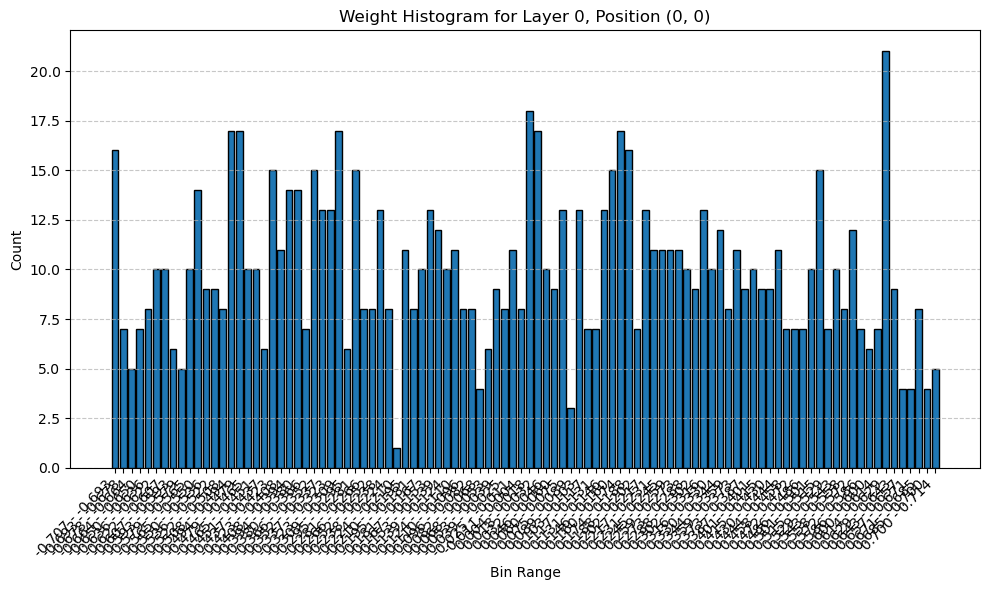

In [20]:
def plot_weight_bins(weight_distributions, layer, weight_position, bin_edges):
    """
    Parameters:
    - weight_distributions: weight counts in the shape (layer, neuron, incoming weight, bin)
    - layer: Index of the layer to plot (0-indexed).
    - weight_position: Tuple indicating the neuron index and incoming weight index in the layer.
    - bin_edges: The edges of the bins for the specified layer, used to label the x-axis with actual values.
    """
    # get the bin data for the specified weight
    weight_distribution = weight_distributions[layer][weight_position[0]][weight_position[1]][:]

    num_bins = len(weight_distribution)

    bin_labels = [f"{bin_edges[i]:.3f} - {bin_edges[i+1]:.3f}" for i in range(num_bins)]
    
    plt.figure(figsize=(10, 6))
    plt.bar(range(num_bins), weight_distribution, width=0.8, align='center', edgecolor='black')
    plt.xlabel('Bin Range')
    plt.ylabel('Count')
    plt.title(f'Weight Histogram for Layer {layer}, Position {weight_position}')
    plt.xticks(range(num_bins), bin_labels, rotation=45, ha='right')  # Rotate for readability
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()  # Adjust layout to prevent label cut-off
    plt.show()

# neuron 10 in layer 1(0) coming from input neuron 2
print(layer_bin_ranges)
#currently bin_edges are global and aren't specific to each layer
plot_weight_bins(layer_weight_distributions, layer=0, weight_position=(0, 0), bin_edges=layer_bin_ranges[0])


Neuron 0, Incoming Weight 0


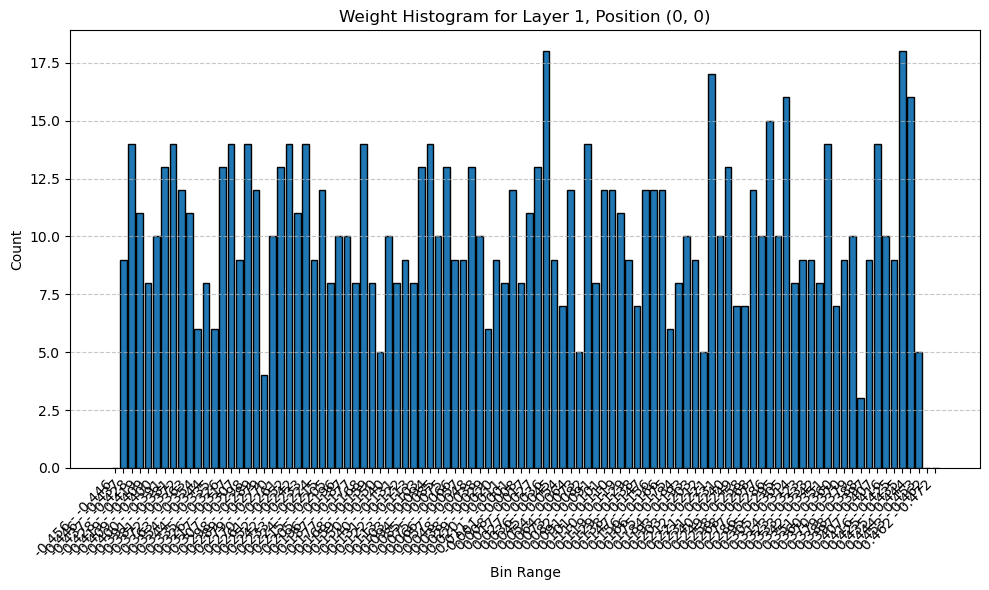

In [ ]:
def weights_walkthrough(weight_distributions, walkthrough_strategy, layer, bin_edges, start_neuron=0):
    """
    Step through the weights of a selected layer using a specified traversal strategy.

    Parameters:
    - weight_distributions: Weight counts in the form (layer, neuron, incoming weight, bin).
    - walkthrough_strategy: 'previous_layer_first' or 'next_layer_first' traversal strategy.
    - layer: Index of the selected layer (0-indexed).
    - bin_edges: The edges of the bins for the selected layer to label the x-axis with actual values.
    - start_neuron: Optional, neuron in the selected layer to start the walkthrough from (default is 0).
    """
    
    num_neurons = weight_distributions[layer].shape[0]  #number of neurons in the selected layer
    num_weights = weight_distributions[layer].shape[1]  #number of weights to each neuron in selected layer

    if walkthrough_strategy == 'previous_layer_first':
        for neuron in range(start_neuron, num_neurons):
            for incoming_weight in range(num_weights):
                print(f"Neuron {neuron}, Incoming Weight {incoming_weight}")
                
                plot_weight_bins(weight_distributions, layer, (neuron, incoming_weight), bin_edges)
                
                user_input = input("Press Enter to continue, or type 'q' to stop: ").strip().lower()
                if user_input == 'q':
                    print("quitting walkthrough.")
                    return
                
    elif walkthrough_strategy == 'next_layer_first':
        for incoming_weight in range(num_weights):
            for neuron in range(start_neuron, num_neurons):
                print(f"Neuron {neuron}, Incoming Weight {incoming_weight}")
                
                plot_weight_bins(weight_distributions, layer, (neuron, incoming_weight), bin_edges)
                
                user_input = input("Press Enter to continue, or type 'q' to stop: ").strip().lower()
                if user_input == 'q':
                    print("quitting walkthrough.")
                    return
                
    else:
        print("Invalid walkthrough strategy. Choose 'previous_layer_first' or 'next_layer_first'.")


weights_walkthrough(layer_weight_distributions, 'previous_layer_first', 1, layer_bin_ranges[1])
# weights_walkthrough(layer_weight_distributions, 'next_layer_first', 0, layer_bin_ranges[0])

In [ ]:
# fc layer 0, neuron 4, from 1
print(layer_weight_distributions[0][4][1])

[   2    4    7   39   94  219  400  588  852 1005 1059 1078 1085 1096
 1127 1189 1090 1155 1140 1192 1160 1173 1103 1135 1125 1126 1181 1176
 1169 1183 1124 1088 1153 1180 1154 1190 1108 1147 1178 1153 1129 1139
 1171 1165 1102 1150 1145 1186 1115 1108 1184 1114 1098 1133 1059 1135
 1111 1138 1115 1167 1161 1185 1108 1129 1117 1166 1146 1159 1115 1202
 1189 1075 1183 1208 1152 1164 1171 1150 1157 1131 1150 1103 1142 1121
 1176 1177 1167 1116 1181 1117 1165 1101 1035  946  673  323  108   34
    6    0]


In [ ]:
normalized_counts = []
for layer in layer_weight_distributions:
    layer_counts = []
    for neuron in layer:
        for from_weight in neuron:
            #total should be num of networks
            total = sum(from_weight)
            normalized_bin_counts = [bin_count / total for bin_count in from_weight]
            layer_counts.append(normalized_bin_counts)
    normalized_counts.append(layer_counts)


# print(len(normalized_counts))
# print(sum(normalized_counts[0]))
# print(normalized_counts[0])

print(layer_bin_ranges[0])
# print(normalized_counts[0])



[-0.83756434 -0.82124741 -0.80493049 -0.78861356 -0.77229664 -0.75597971
 -0.73966279 -0.72334586 -0.70702894 -0.69071201 -0.67439509 -0.65807816
 -0.64176124 -0.62544431 -0.60912739 -0.59281046 -0.57649354 -0.56017661
 -0.54385969 -0.52754276 -0.51122584 -0.49490891 -0.47859199 -0.46227506
 -0.44595814 -0.42964121 -0.41332429 -0.39700736 -0.38069044 -0.36437351
 -0.34805659 -0.33173966 -0.31542274 -0.29910581 -0.28278889 -0.26647196
 -0.25015504 -0.23383811 -0.21752119 -0.20120426 -0.18488734 -0.16857041
 -0.15225348 -0.13593656 -0.11961963 -0.10330271 -0.08698578 -0.07066886
 -0.05435193 -0.03803501 -0.02171808 -0.00540116  0.01091577  0.02723269
  0.04354962  0.05986654  0.07618347  0.09250039  0.10881732  0.12513424
  0.14145117  0.15776809  0.17408502  0.19040194  0.20671887  0.22303579
  0.23935272  0.25566964  0.27198657  0.28830349  0.30462042  0.32093734
  0.33725427  0.35357119  0.36988812  0.38620504  0.40252197  0.41883889
  0.43515582  0.45147274  0.46778967  0.48410659  0

In [50]:
from scipy.stats import norm
from scipy.optimize import curve_fit

def normal_pdf(x, mu, sigma, amplitude):
    return amplitude * norm.pdf(x, mu, sigma)

In [62]:
def return_weight_bins_plot(weight_distributions, layer, weight_position, bin_edges):
    """
    Parameters:
    - weight_distributions: weight counts in the shape (layer, neuron, incoming weight, bin)
    - layer: Index of the layer to plot (0-indexed).
    - weight_position: Tuple indicating the neuron index and incoming weight index in the layer.
    - bin_edges: The edges of the bins for the specified layer, used to label the x-axis with actual values.
    """
    weight_distribution = weight_distributions[layer][weight_position[0]][weight_position[1]][:]

    num_bins = len(weight_distribution)

    bin_labels = [f"{bin_edges[i]:.3f} - {bin_edges[i+1]:.3f}" for i in range(num_bins)]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(range(num_bins), weight_distribution, width=0.8, align='center', edgecolor='black')
    ax.set_xlabel('Bin Range')
    ax.set_ylabel('Count')
    ax.set_title(f'Weight Histogram for Layer {layer}, Position {weight_position}')
    ax.set_xticks(range(num_bins))
    ax.set_xticklabels(bin_labels, rotation=45, ha='right')  # Rotate for readability
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    fig.tight_layout()  # Adjust layout to prevent label cut-off
    
    return fig, ax

In [ ]:


for layer_index in range(len(layer_weight_distributions)):
    counts = np.array(normalized_counts[layer_index])

    min_val_layer = np.min(layer_bin_ranges[layer_index])
    max_val_layer = np.max(layer_bin_ranges[layer_index])

    bin_centers = (layer_bin_ranges[layer_index][:-1] + layer_bin_ranges[layer_index][1:]) / 2
    print(np.max(counts))

    initial = [np.mean(bin_centers), np.std(bin_centers), np.max(counts)]

    fits, covariance = curve_fit(normal_pdf, bin_centers, counts, p0=initial)

    mu_fit, sigma_fit, amplitude_fit = fits
    print(f"Fitted parameters:\nMu = {mu_fit}\nSigma = {sigma_fit}\nAmplitude = {amplitude_fit}")

    y_fit = normal_pdf(bin_centers, mu_fit, sigma_fit, amplitude_fit)
    print(y_fit)

    fig, ax = return_weight_bins_plot(layer_weight_distributions, layer_index, (0, 0), layer_bin_ranges[layer_index])

    ax.plot(bin_centers, y_fit, color='red', linewidth=2, label='Fitted Normal Distribution')

    ax.legend()
    plt.show()

    

